tensor([[ 0.5156,  0.8499],
        [ 0.5527,  0.8327],
        [-0.0427,  0.9967],
        ...,
        [-0.9948, -0.1016],
        [-0.8330,  0.5533],
        [ 0.9576, -0.2881]], dtype=torch.float64)
conf
objects
model
embeddings
epoch
model_type


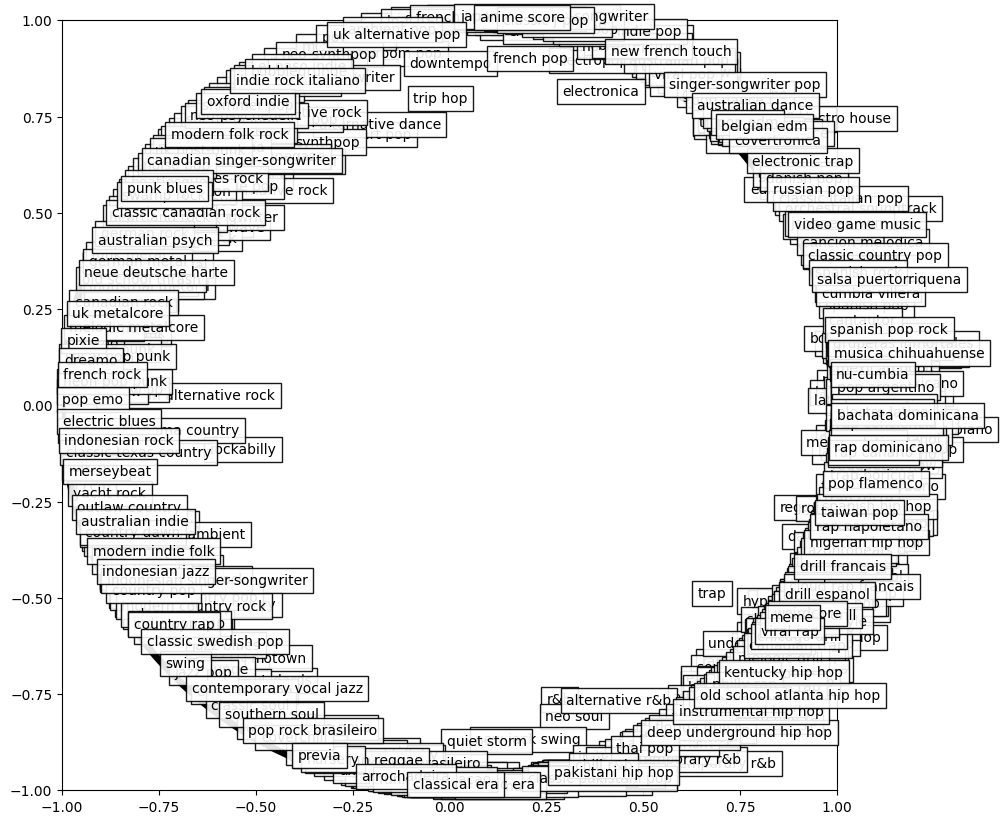

In [35]:
import matplotlib.pyplot as plt
import torch
from matplotlib.patches import Circle

model = torch.load("genres.pth")
print(model['model']['lt.weight'])
for item in model:
    print(item)
coordinates = model["model"]["lt.weight"].numpy()

fig, ax = plt.subplots(figsize=(10, 10))

plt.xlim(-1, 1)
plt.ylim(-1, 1)
# plt.axis('off')

for x in range(coordinates.shape[0]):
    plt.annotate(model["objects"][x], (coordinates[x,0], coordinates[x,1]),
                 bbox={"fc":"white", "alpha":0.9})
    
circle = Circle((0, 0), 1.0, edgecolor='black', facecolor='none', lw=5)
ax.add_patch(circle)

plt.show()
# plt.savefig("genres.png")


In [19]:
gtzan_genres = ['blues', 'classical', 'country', 'disco', 'hip hop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
genre_coords = []
for genre in gtzan_genres:
    if genre in model['objects']:
        genreidx = model['objects'].index(genre)
        genre_coord = (coordinates[genreidx, 0], coordinates[genreidx, 1])
        print(genre_coord[0] ** 2 + genre_coord[1] ** 2)
        genre_coords.append(genre_coord)
    else:
        print(f'{genre} not in model')

0.8752174008837956
0.9876436048932524
0.7373192028389761
0.9384538417212207
0.9135259193050538
0.8651231030238538
0.9578524971324562
0.9881764642086553
0.8029486814666573
0.8754121928236822


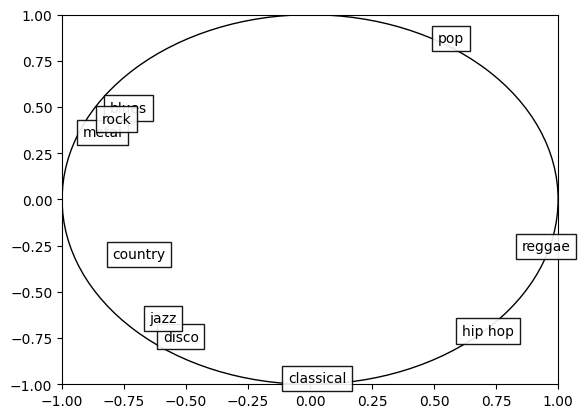

In [36]:
fig, ax = plt.subplots()

plt.xlim(-1, 1)
plt.ylim(-1, 1)
for i in range(len(gtzan_genres)):
    plt.annotate(gtzan_genres[i], genre_coords[i],
                 bbox={"fc":"white", "alpha":0.9})
    
circle = Circle((0, 0), 1.0, edgecolor='black', facecolor='none')
ax.add_patch(circle)

plt.show()

In [20]:
import numpy as np

def hyperbolic_distance(z1, z2):
    # z1 and z2 are complex numbers or (x, y) tuples
    x1, y1 = z1
    x2, y2 = z2
    norm_a_sq = x1**2 + y1**2
    norm_b_sq = x2**2 + y2**2
    euclidean_sq = (x1 - x2)**2 + (y1 - y2)**2
    return np.arccosh(1 + 2 * euclidean_sq / ((1 - norm_a_sq) * (1 - norm_b_sq)))

In [25]:
for i, genre in enumerate(gtzan_genres):
    print(genre, hyperbolic_distance(genre_coords[2], genre_coords[i]))

hyperbolic_distance(genre_coords[0], genre_coords[2])

blues 4.362699033271597
classical 7.068592329645936
country 0.0
disco 4.121515215086378
hip hop 5.9468929719995725
jazz 2.8966165780354336
metal 5.1047244014523265
pop 8.289076467134866
reggae 5.359427849193738
rock 4.215701458741365


np.float64(4.362699033271597)

In [52]:
point_genre_map = (genre_coords, gtzan_genres)

In [53]:
import pickle

with open('point_genre_map.pkl', 'wb') as f:
    pickle.dump(point_genre_map, f)

In [45]:
point_genre_map

[[(np.float64(-0.8069500424487297), np.float64(0.47333817707405457)),
  (np.float64(-0.09000353822701311), np.float64(-0.9897186307228287)),
  (np.float64(-0.7975122788968765), np.float64(-0.31826619023654845)),
  (np.float64(-0.5940467453361659), np.float64(-0.7652204297303681)),
  (np.float64(0.6126849884730791), np.float64(-0.7335823227183141)),
  (np.float64(-0.6489588146800174), np.float64(-0.6663149104387209)),
  (np.float64(-0.9168822170133929), np.float64(0.34231490948695437)),
  (np.float64(0.5155795848706602), np.float64(0.8499142050073366)),
  (np.float64(0.8527880848594581), np.float64(-0.2751384447662576)),
  (np.float64(-0.8390359084253661), np.float64(0.41404219253175495))],
 ['blues',
  'classical',
  'country',
  'disco',
  'hip hop',
  'jazz',
  'metal',
  'pop',
  'reggae',
  'rock']]